# ACM — Flight Price Prediction
**Lead University · Minería de Datos · Tarea 4**

Análisis de Correspondencias Múltiples sobre datos de vuelos comerciales.
Objetivo: explorar asociaciones entre variables categóricas del servicio aéreo (aerolínea, ruta, clase, horarios) y detectar perfiles de vuelos.

In [15]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import ACMAnalyzer
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

print('Librerías cargadas.')

Librerías cargadas.


---
## Parte 1 — Preparación de datos

### 1. Carga y exploración

In [16]:
df_raw = pd.read_csv('datos/datos_vuelos_comerciales.csv', index_col=0)
print(f'Registros: {df_raw.shape[0]:,} | Variables: {df_raw.shape[1]}')
print()
print(df_raw.dtypes)
print()
df_raw.head()

Registros: 300,153 | Variables: 11

airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
dtype: object



,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [17]:
print('Valores faltantes:')
print(df_raw.isnull().sum())
print()
print('Valores únicos por variable categórica:')
for c in df_raw.select_dtypes(include='object').columns:
    print(f'  {c}: {df_raw[c].nunique()} -> {df_raw[c].unique().tolist()}')

Valores faltantes:
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Valores únicos por variable categórica:
  airline: 6 -> ['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']
  flight: 1561 -> ['SG-8709', 'SG-8157', 'I5-764', 'UK-995', 'UK-963', 'UK-945', 'UK-927', 'UK-951', 'G8-334', 'G8-336', 'G8-392', 'G8-338', '6E-5001', '6E-6202', '6E-549', '6E-6278', 'AI-887', 'AI-665', 'I5-747', 'G8-266', 'G8-101', 'G8-103', 'AI-441', '6E-5328', 'UK-933', '6E-2046', 'I5-744', 'SG-8169', '6E-5041', 'G8-165', '6E-2373', 'UK-813', 'UK-817', 'UK-819', 'UK-801', 'UK-815', 'AI-453', 'SG-2976', 'AI-504', 'AI-502', 'AI-506', 'AI-803', 'AI-479', 'SG-339', 'UK-955', 'UK-627', 'I5-784', 'AI-9643', 'AI-540', 'AI-429', 'AI-439', 'AI-9645', '6E-2193', '6E-2168', '6E-152', '6E-369', 'UK-8

### 2. Limpieza

El dataset no presenta valores faltantes. Se elimina la columna `flight` (identificador de vuelo, no aporta información categórica interpretable). Las variables numéricas (`duration`, `days_left`, `price`) serán discretizadas automáticamente por `ACMAnalyzer` en cuartiles para incorporarlas al ACM.

### 3-4. Selección de variables y discretización

Se conservan las variables categóricas naturales (`airline`, `source_city`, `departure_time`, `stops`, `arrival_time`, `destination_city`, `class`) y las numéricas (`duration`, `days_left`, `price`) que `ACMAnalyzer` discretiza automáticamente en cuartiles.

**Nota sobre el tamaño muestral:** Se realizó una prueba comparativa entre una muestra de 15K registros y el dataset completo (300K). Los resultados fueron prácticamente idénticos, no obstante, se decidió usar todos los registros para evitar cualquier pérdida de información en modalidades de baja frecuencia.

In [18]:
df = df_raw.drop(columns=['flight']).reset_index(drop=True)
print(f'Registros: {len(df):,}')
print(f'Variables: {df.shape[1]}')

Registros: 300,153
Variables: 10


---
## Parte 2 — Aplicación del ACM

### 6. ¿Qué es el ACM?

El **Análisis de Correspondencias Múltiples (ACM)** es una técnica de reducción de dimensionalidad diseñada para variables categóricas. Generaliza el Análisis de Correspondencias Simple (ACS) a más de dos variables.

**Objetivo:** Representar individuos y modalidades (categorías) en un espacio de pocas dimensiones, de modo que las distancias reflejen las asociaciones entre ellos (medidas vía chi-cuadrado). Puntos cercanos = perfiles similares; puntos opuestos = perfiles contrastantes.

**¿Por qué es apropiado para este dataset?** Las variables principales son categóricas nominales (aerolínea, ciudad, horario, clase). El PCA requiere variables numéricas y asume relaciones lineales; el ACM respeta la naturaleza categórica de los datos y detecta asociaciones no lineales entre modalidades.

### 5. Ajuste del ACM

In [19]:
fx = ACMAnalyzer(df)
fx.fit(n_plot=2)

display(fx.summary())

,metodo,dim1,dim2,acum_1_2
0,PCA,9.62,5.55,15.17
1,ACM,7.27,4.61,11.88


### 7. Tabla de inercia explicada por componente

In [20]:
fx.plot_inertia(n=10)

PCA


,autovalor,% total,% acum
0,3.654,9.616,9.616
1,2.109,5.550,15.165
2,1.765,4.644,19.809
3,1.658,4.364,24.173
4,1.622,4.268,28.441
5,1.572,4.136,32.577
6,1.501,3.951,36.528
7,1.464,3.853,40.380
8,1.437,3.782,44.163
9,1.359,3.577,47.739


ACM


,autovalor,% total,% acum
0,0.269,7.267,7.267
1,0.171,4.612,11.879
2,0.159,4.299,16.177
3,0.156,4.203,20.381
4,0.136,3.681,24.061
5,0.134,3.617,27.678
6,0.131,3.533,31.211
7,0.126,3.418,34.630
8,0.123,3.325,37.955
9,0.121,3.274,41.228


### 8. Scree plot

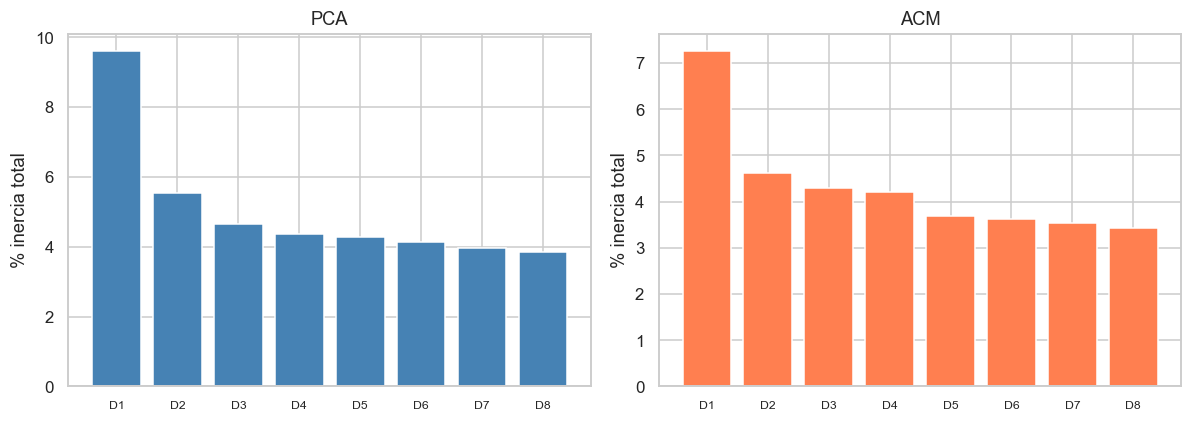

In [21]:
fx.plot_scree()

### 9. Elección de componentes

**Nota sobre la inercia en ACM:** A diferencia del PCA donde los primeros componentes suelen acumular >80% rápidamente, en ACM la inercia se distribuye de forma más uniforme entre muchas dimensiones. Esto es inherente al método: la inercia total se divide entre (total_modalidades - num_variables) dimensiones posibles. Por lo tanto, porcentajes bajos (5-15% por dimensión) son normales y no implican falta de estructura.

Se seleccionan las **primeras 2 dimensiones** como plano principal de interpretación:
1. D1 (7.3%) se destaca claramente del resto — hay un salto de ~2.7 puntos respecto a D2 (4.6%).
2. A partir de D2, la caída es muy gradual (4.6%, 4.3%, 4.2%...) sin un segundo codo claro.
3. D1 y D2 acumulan ~12% de inercia, suficiente para capturar el contraste principal (business vs economy) y la separación por escalas/horarios.
4. Una tercera dimensión podría aportar información sobre rutas, pero el biplot 2D ya muestra la estructura principal.

---
## Parte 3 — Interpretación del espacio factorial

### 10-11. Biplot del ACM (individuos + categorías)

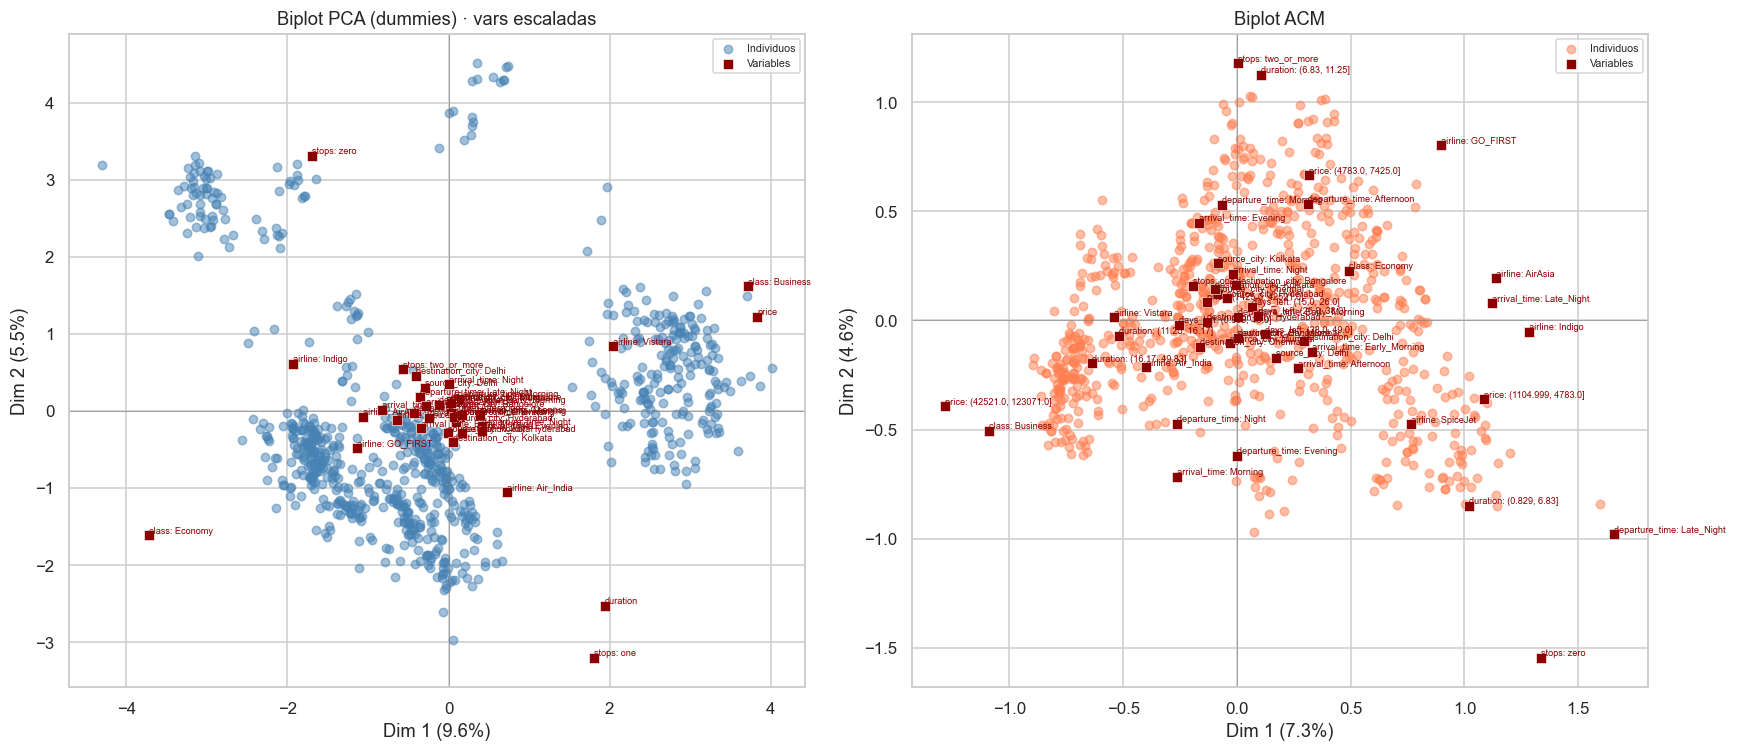

In [22]:
fx.plot_biplots()

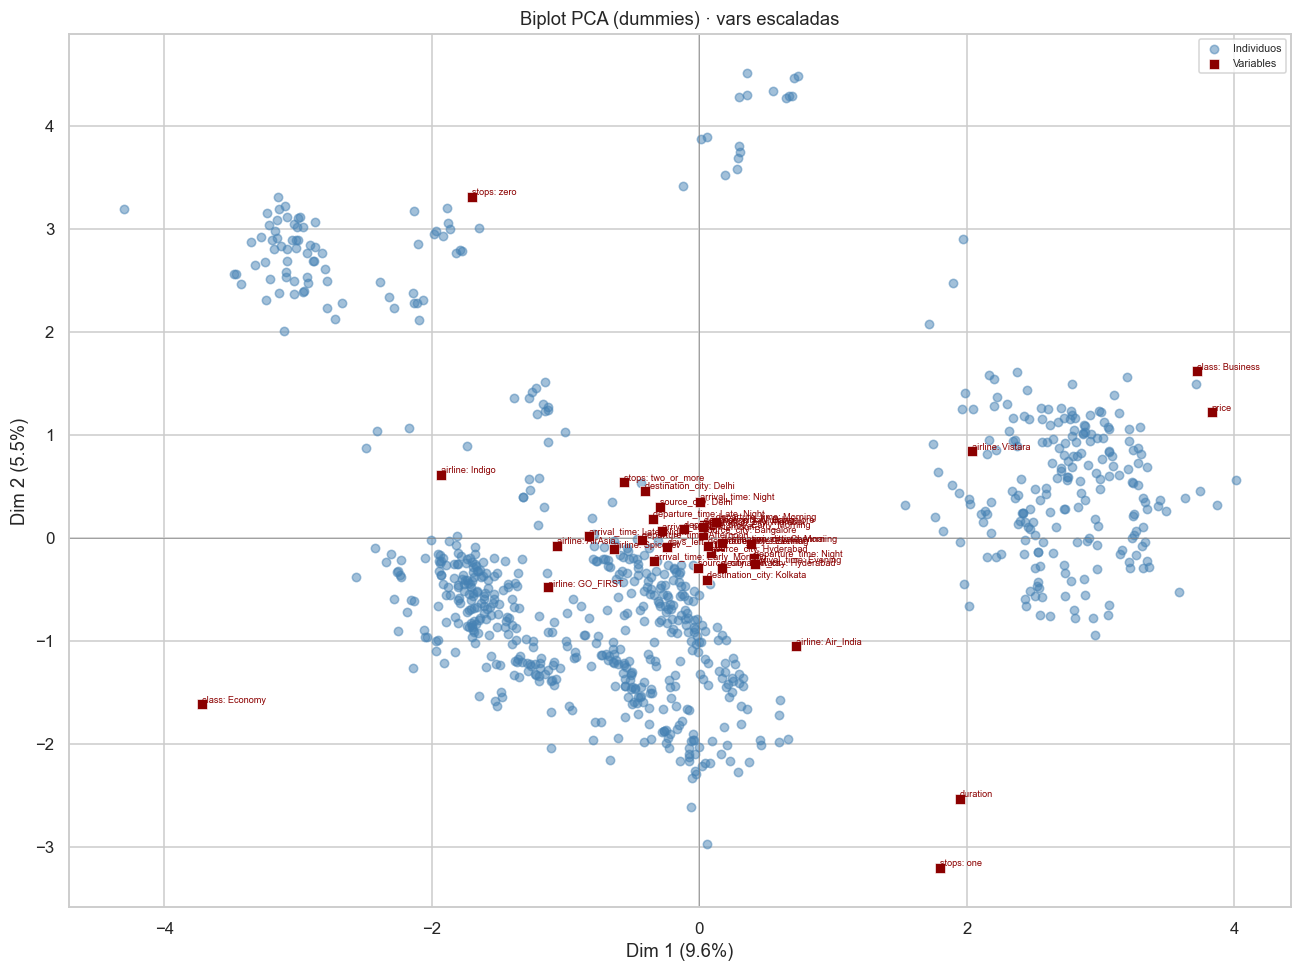

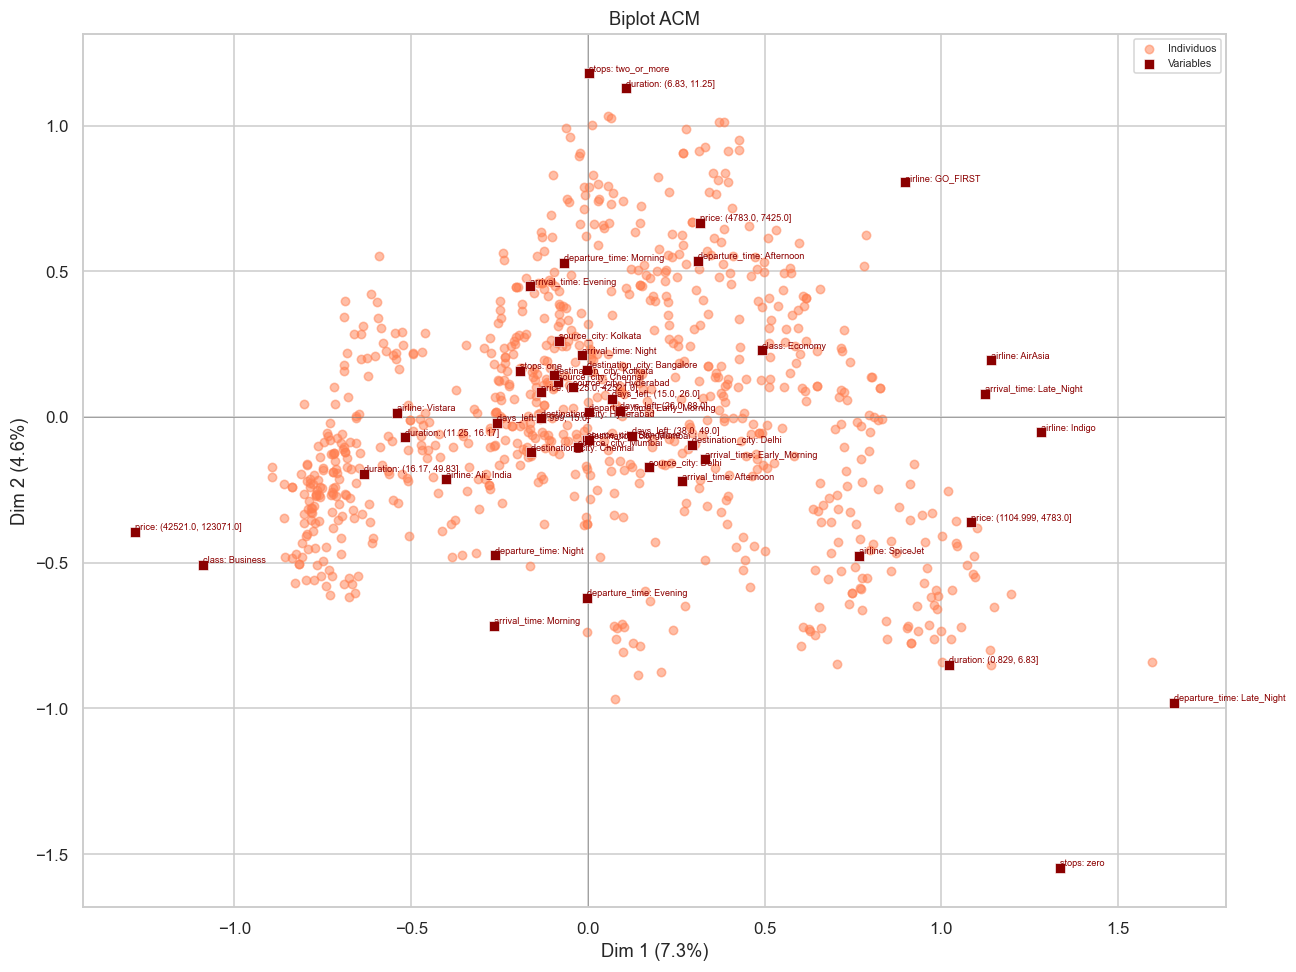

In [23]:
fx.plot_biplots(individual=True)

**Interpretación del biplot ACM:**

**Dim 1 (7.3%) — Eje de segmento de mercado (business vs low-cost):**
- A la izquierda: `class: Business`, `price: (42521, 123071]`, `airline: Vistara`, `airline: Air_India`, `duration: (16.17, 49.83]`. Perfil de vuelo premium: aerolíneas de servicio completo, precios altos, duración larga (más escalas).
- A la derecha: `airline: Indigo`, `airline: AirAsia`, `airline: SpiceJet`, `price: (1105, 4783]`, `duration: (0.83, 6.83]`, `stops: zero`. Perfil low-cost: aerolíneas económicas, vuelos directos y cortos, precios bajos.
- `class: Economy` está a la derecha pero más cerca del centro (es la modalidad dominante).

**Dim 2 (4.6%) — Eje de escalas y horarios:**
- Arriba: `stops: two_or_more`, `duration: (6.83, 11.25]`, `airline: GO_FIRST`, `departure_time: Morning/Afternoon`. Vuelos con escala(s), duración media-larga, salida diurna.
- Abajo: `stops: zero`, `departure_time: Late_Night`, `arrival_time: Morning`, `airline: SpiceJet`. Vuelos directos nocturnos.

**Asociaciones principales:**
- `class: Business` ↔ `price: premium` ↔ `Vistara` forman un cluster a la izquierda — las aerolíneas premium concentran casi todo el segmento business.
- Las aerolíneas low-cost (Indigo, AirAsia, SpiceJet) se agrupan a la derecha con vuelos directos y precios bajos, pero se separan en Dim 2 por diferencias en horarios y rutas.
- Las ciudades y horarios de salida/llegada se concentran cerca del origen — no definen los ejes principales, indicando que la ruta es menos diferenciadora que el segmento de servicio.

### Comparación ACM vs PCA

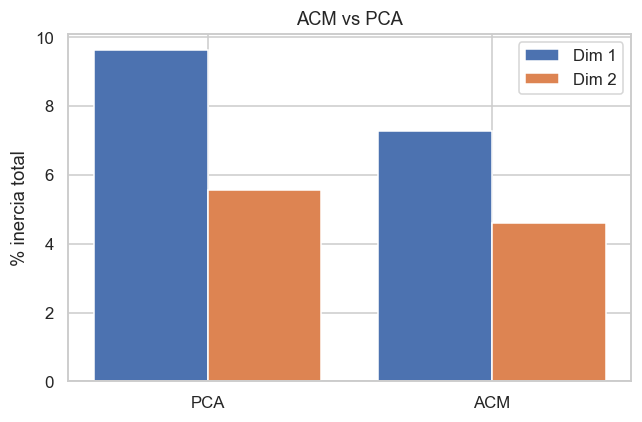

In [24]:
fx.plot_comparison()

### 12. Contribuciones y calidad de representación (cos²)

In [25]:
fx.show_contrib_cos2(n=12)

Contribuciones de variables (dims 1-2): PCA vs ACM


,PCA_variable,PCA_contrib,ACM_variable,ACM_contrib
rank,,,,
1,stops: zero,0.3312,stops: zero,0.2477
2,stops: one,0.3181,"duration: (0.829, 6.83]",0.2057
3,class: Business,0.2785,"duration: (6.83, 11.25]",0.1869
4,class: Economy,0.2785,class: Business,0.1840
5,price,0.2613,"price: (42521.0, 123071.0]",0.1740
6,duration,0.2255,"price: (1104.999, 4783.0]",0.1284
7,airline: Vistara,0.0816,airline: Indigo,0.0881
8,airline: Indigo,0.0665,class: Economy,0.0832
9,airline: Air_India,0.0368,"price: (4783.0, 7425.0]",0.0744


Resumen cos² de individuos en el plano 1-2


,metodo,cos2_media,cos2_mediana,cos2_min,pct_cos2>=0.5
0,PCA,0.1491,0.1014,0.0,0.3092
1,ACM,0.1204,0.1096,0.0,0.0000


Top 12 individuos por cos²: PCA vs ACM


,PCA_individuo,PCA_cos2,ACM_individuo,ACM_cos2
rank,,,,
1,227176,0.5788,50751,0.481
2,226965,0.5783,51871,0.481
3,227610,0.5781,51002,0.481
4,226857,0.5777,51630,0.481
5,227716,0.5776,52489,0.481
6,227821,0.5768,52696,0.481
7,225852,0.5765,50578,0.481
8,226644,0.5762,51862,0.481
9,226643,0.5762,51171,0.481


### 13. Perfiles similares en el espacio reducido

El ACM identifica claramente dos perfiles principales separados por Dim 1:

1. **Perfil business/premium (izquierda):** Vuelos de Vistara y Air India, clase Business, precios >43K, duraciones largas (>11h, múltiples escalas). Grupo compacto y separado del centro.
2. **Perfil economy/low-cost (derecha):** Aerolíneas Indigo, SpiceJet, AirAsia. Vuelos directos, cortos (<7h), precios bajos (<5K). Grupo más disperso porque incluye variedad de rutas y horarios.

Dentro del perfil economy, Dim 2 separa un sub-perfil de **vuelos nocturnos directos** (abajo: SpiceJet, Late_Night, zero stops) de los **vuelos con escala en horario diurno** (arriba: GO_FIRST, Morning/Afternoon, one/two_or_more stops).

El cos² bajo en el plano (media = 0.12, ningún individuo alcanza 0.5) indica que dos dimensiones no son suficientes para representar fielmente todos los perfiles — hay estructura adicional en dimensiones posteriores, probablemente relacionada con rutas específicas.